# Deep Reinforcement Learning Laboratory

In this laboratory session we will work on getting more advanced versions of Deep Reinforcement Learning algorithms up and running. Deep Reinforcement Learning is **hard**, and getting agents to stably train can be frustrating and requires quite a bit of subtlety in analysis of intermediate results. We will start by refactoring (a bit) my implementation of `REINFORCE` on the [Cartpole environment](https://gymnasium.farama.org/environments/classic_control/cart_pole/). 

## Exercise 1: Improving my `REINFORCE` Implementation (warm up)

In this exercise we will refactor a bit and improve some aspects of my `REINFORCE` implementation. 

**First Things First**: Spend some time playing with the environment to make sure you understand how it works.

IMPORT

In [6]:
%reload_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import os

PROJECT_DIR = Path("/mnt/c/Users/checc/OneDrive/Desktop/Reinforcment LLM/DLA_3")

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project folder not found: {PROJECT_DIR}")

if not (PROJECT_DIR / "reinforce.py").exists():
    raise FileNotFoundError(f"reinforce.py not found in: {PROJECT_DIR}")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt

from reinforce import PolicyNet, ValueNet, reinforce, reinforce_baseline, run_episode, run_episode_greedy

print("Import OK!")

Import OK!


Ambiente cartpole

In [7]:
env = gym.make("CartPole-v1")

obs, info = env.reset(seed=42)

print(f"Observation: {obs}")
print(f"Observation space: {env.observation_space}")
print(f"Obs low:  {env.observation_space.low}")
print(f"Obs high: {env.observation_space.high}")
print(f"Action space: {env.action_space}")

for i in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    print(
        f"Step {i+1} | "
        f"action: {action} | "
        f"obs: {obs.round(3)} | "
        f"reward: {reward} | "
        f"terminated: {terminated}"
    )

    if terminated or truncated:
        obs, info = env.reset()

env.close()

Observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Obs low:  [-4.8               -inf -0.41887903        -inf]
Obs high: [4.8               inf 0.41887903        inf]
Action space: Discrete(2)
Step 1 | action: 1 | obs: [ 0.027  0.188  0.036 -0.261] | reward: 1.0 | terminated: False
Step 2 | action: 0 | obs: [ 0.031 -0.007  0.031  0.042] | reward: 1.0 | terminated: False
Step 3 | action: 1 | obs: [ 0.031  0.188  0.032 -0.24 ] | reward: 1.0 | terminated: False
Step 4 | action: 0 | obs: [ 0.035 -0.008  0.027  0.062] | reward: 1.0 | terminated: False
Step 5 | action: 1 | obs: [ 0.034  0.187  0.028 -0.222] | reward: 1.0 | terminated: False


In [8]:
env = gym.make("CartPole-v1")
policy = PolicyNet(env)

print(policy)

PolicyNet(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [9]:
env_render = gym.make("CartPole-v1", render_mode="human")

Reinforce

In [10]:
from pathlib import Path
import sys

PROJECT_DIR = Path("/mnt/c/Users/checc/OneDrive/Desktop/Reinforcment LLM/DLA_3")

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from reinforce import PolicyNet, reinforce, run_episode, run_episode_greedy

print("Import OK!")

Import OK!


**Next Things Next**: Now get your `REINFORCE` implementation working on the environment. You can import my (probably buggy and definitely inefficient) implementation here. Or even better, refactor an implementation into a separate package from which you can `import` the stuff you need here. 

In [11]:
seed = 2112
torch.manual_seed(seed)
np.random.seed(seed)

env = gym.make('CartPole-v1')
env.reset(seed=seed)

policy = PolicyNet(env)
results = reinforce(policy, env, num_episodes=1000)

env.close()

  [EVAL ep.0] AvgReturn: 9.0 | AvgLength: 9.0
💾 New best eval model saved! AvgEvalReturn = 9.00

Episode: 0
Train Return: 23.00
Train Avg Return (last 50): 23.00
Train Std Return (last 50): 0.00
Episode Length: 23
Loss: -0.0017
Running Reward: 1.15

  [EVAL ep.50] AvgReturn: 9.1 | AvgLength: 9.1
💾 New best eval model saved! AvgEvalReturn = 9.10

Episode: 50
Train Return: 14.00
Train Avg Return (last 50): 22.62
Train Std Return (last 50): 11.24
Episode Length: 14
Loss: -0.1460
Running Reward: 21.00

  [EVAL ep.100] AvgReturn: 61.2 | AvgLength: 61.2
💾 New best eval model saved! AvgEvalReturn = 61.20

Episode: 100
Train Return: 29.00
Train Avg Return (last 50): 20.62
Train Std Return (last 50): 11.26
Episode Length: 29
Loss: 0.1030
Running Reward: 21.46

  [EVAL ep.150] AvgReturn: 109.6 | AvgLength: 109.6
💾 New best eval model saved! AvgEvalReturn = 109.60

Episode: 150
Train Return: 27.00
Train Avg Return (last 50): 21.56
Train Std Return (last 50): 10.06
Episode Length: 27
Loss: -0.2715

**Last Things Last**: My implementation does a **super crappy** job of evaluating the agent performance during training. The running average is not a very good metric. Modify my implementation so that every $N$ iterations (make $N$ an argument to the training function) the agent is run for $M$ episodes in the environment. Collect and return: (1) The average **total** reward received over the $M$ iterations; and (2) the average episode length. Analyze the performance of your agents with these new metrics.

RELOAD

In [12]:
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt

from reinforce import PolicyNet, reinforce, run_episode_greedy

print("Import OK!")

Import OK!


TRAIN

In [13]:
SEED = 2112  

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / f"cartpole_reinforce_seed{SEED}_best.pt"

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Checkpoint path:", CHECKPOINT_PATH)

Checkpoint path: checkpoints/cartpole_reinforce_seed2112_best.pt


In [14]:
env = gym.make("CartPole-v1")
env.reset(seed=SEED)
env.action_space.seed(SEED)

policy = PolicyNet(env)

results = reinforce(
    policy=policy,
    env=env,
    gamma=0.98,
    num_episodes=1000,
    eval_every=50,
    eval_episodes=10,
    checkpoint_path=str(CHECKPOINT_PATH),
    log_every=50,
    save_best_on_eval=True
)

env.close()

print(results.keys())
print("Best checkpoint saved in:", results["checkpoint_path"])
print("Best eval return:", results["best_eval_return"])

  [EVAL ep.0] AvgReturn: 9.0 | AvgLength: 9.0
💾 New best eval model saved! AvgEvalReturn = 9.00

Episode: 0
Train Return: 23.00
Train Avg Return (last 50): 23.00
Train Std Return (last 50): 0.00
Episode Length: 23
Loss: -0.0017
Running Reward: 1.15

  [EVAL ep.50] AvgReturn: 9.1 | AvgLength: 9.1
💾 New best eval model saved! AvgEvalReturn = 9.10

Episode: 50
Train Return: 14.00
Train Avg Return (last 50): 22.62
Train Std Return (last 50): 11.24
Episode Length: 14
Loss: -0.1460
Running Reward: 21.00

  [EVAL ep.100] AvgReturn: 61.2 | AvgLength: 61.2
💾 New best eval model saved! AvgEvalReturn = 61.20

Episode: 100
Train Return: 29.00
Train Avg Return (last 50): 20.62
Train Std Return (last 50): 11.26
Episode Length: 29
Loss: 0.1030
Running Reward: 21.46

  [EVAL ep.150] AvgReturn: 109.6 | AvgLength: 109.6
💾 New best eval model saved! AvgEvalReturn = 109.60

Episode: 150
Train Return: 27.00
Train Avg Return (last 50): 21.56
Train Std Return (last 50): 10.06
Episode Length: 27
Loss: -0.2715

GRAFICI

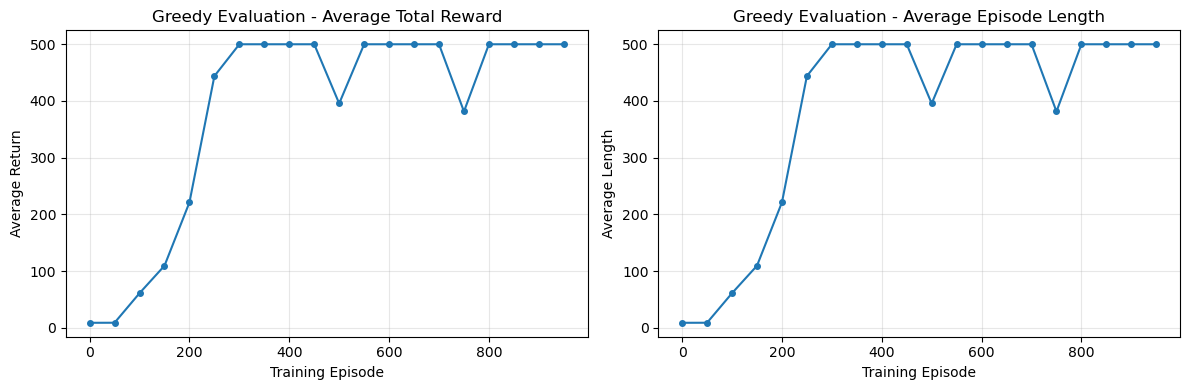

Final eval avg return: 500.0
Final eval avg length: 500.0


In [15]:
eval_x = results["eval_episode_indices"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(eval_x, results["eval_avg_returns"], marker="o", markersize=4)
plt.title("Greedy Evaluation - Average Total Reward")
plt.xlabel("Training Episode")
plt.ylabel("Average Return")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(eval_x, results["eval_avg_lengths"], marker="o", markersize=4)
plt.title("Greedy Evaluation - Average Episode Length")
plt.xlabel("Training Episode")
plt.ylabel("Average Length")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final eval avg return: {results['eval_avg_returns'][-1]:.1f}")
print(f"Final eval avg length: {results['eval_avg_lengths'][-1]:.1f}")

Cartpole

In [16]:
import time

def watch_saved_cartpole(checkpoint_path, episodes=3, delay=0.02):
    env_watch = gym.make("CartPole-v1", render_mode="human")

    policy_best = PolicyNet(env_watch)

    state_dict = torch.load(checkpoint_path, map_location="cpu")
    policy_best.load_state_dict(state_dict)
    policy_best.eval()

    OBS_SCALE = torch.tensor([4.8, 5.0, 0.418, 5.0], dtype=torch.float32)

    for ep in range(episodes):
        obs, info = env_watch.reset()
        total_reward = 0

        for t in range(500):
            obs_tensor = torch.tensor(obs, dtype=torch.float32) / OBS_SCALE

            with torch.no_grad():
                action = policy_best(obs_tensor, temperature=1e-8).argmax().item()

            obs, reward, terminated, truncated, info = env_watch.step(action)
            total_reward += reward

            time.sleep(delay)

            if terminated or truncated:
                break

        print(f"Episode {ep + 1}: return = {total_reward:.0f}, length = {t + 1}")

    env_watch.close()


watch_saved_cartpole(CHECKPOINT_PATH, episodes=3, delay=0.02)

Episode 1: return = 500, length = 500
Episode 2: return = 500, length = 500
Episode 3: return = 500, length = 500


-----
## Exercise 2: `REINFORCE` with a Value Baseline (warm up)

In this exercise we will augment my implementation (or your own) of `REINFORCE` to subtract a baseline from the target in the update equation in order to stabilize (and hopefully speed-up) convergence. For now we will stick to the Cartpole environment.



**First Things First**: Recall from the slides on Deep Reinforcement Learning that we can **subtract** any function that doesn't depend on the current action from the q-value without changing the (maximum of our) objecttive function $J$:  

$$ \nabla J(\boldsymbol{\theta}) \propto \sum_{s} \mu(s) \sum_a \left( q_{\pi}(s, a) - b(s) \right) \nabla \pi(a \mid s, \boldsymbol{\theta}) $$

In `REINFORCE` this means we can subtract from our target $G_t$:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - b(S_t)) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

Since we are only interested in the **maximum** of our objective, we can also **rescale** our target by any function that also doesn't depend on the action. A **simple baseline** which is even independent of the state -- that is, it is **constant** for each episode -- is to just **standardize rewards within the episode**. So, we **subtract** the average return and **divide** by the variance of returns:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha \left(\frac{G_t - \bar{G}}{\sigma_G}\right) \nabla  \pi(A_t \mid s, \boldsymbol{\theta}) $$

This baseline is **already** implemented in my implementation of `REINFORCE`. Experiment with and without this standardization baseline and compare the performance. We are going to do something more interesting.

In [17]:
%load_ext autoreload
%autoreload 2

import importlib
import reinforce as reinforce_module
importlib.reload(reinforce_module)

from reinforce import PolicyNet, reinforce, run_episode_greedy

print("reinforce.py reloaded correctly!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
reinforce.py reloaded correctly!


In [18]:
%reload_ext autoreload
%autoreload 2

Standardize e Non-Standardize

In [19]:
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt

SEED = 2112
NUM_EPISODES = 500
EVAL_EVERY = 50
EVAL_EPISODES = 10

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)


def train_reinforce_variant(name, standardize, seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make("CartPole-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    policy = PolicyNet(env)

    checkpoint_path = CHECKPOINT_DIR / f"cartpole_reinforce_{name}_seed{seed}_best.pt"

    results = reinforce(
        policy=policy,
        env=env,
        gamma=0.98,
        num_episodes=NUM_EPISODES,
        eval_every=EVAL_EVERY,
        eval_episodes=EVAL_EPISODES,
        standardize=standardize,
        checkpoint_path=str(checkpoint_path),
        log_every=50,
        save_best_on_eval=True
    )

    env.close()

    return policy, results

In [20]:
policy_std, results_std = train_reinforce_variant(
    name="standardized",
    standardize=True
)

policy_nostd, results_nostd = train_reinforce_variant(
    name="not_standardized",
    standardize=False
)

  [EVAL ep.0] AvgReturn: 9.0 | AvgLength: 9.0
💾 New best eval model saved! AvgEvalReturn = 9.00

Episode: 0
Train Return: 23.00
Train Avg Return (last 50): 23.00
Train Std Return (last 50): 0.00
Episode Length: 23
Loss: -0.0017
Running Reward: 1.15

  [EVAL ep.50] AvgReturn: 9.1 | AvgLength: 9.1
💾 New best eval model saved! AvgEvalReturn = 9.10

Episode: 50
Train Return: 14.00
Train Avg Return (last 50): 22.62
Train Std Return (last 50): 11.24
Episode Length: 14
Loss: -0.1460
Running Reward: 21.00

  [EVAL ep.100] AvgReturn: 61.2 | AvgLength: 61.2
💾 New best eval model saved! AvgEvalReturn = 61.20

Episode: 100
Train Return: 29.00
Train Avg Return (last 50): 20.62
Train Std Return (last 50): 11.26
Episode Length: 29
Loss: 0.1030
Running Reward: 21.46

  [EVAL ep.150] AvgReturn: 109.6 | AvgLength: 109.6
💾 New best eval model saved! AvgEvalReturn = 109.60

Episode: 150
Train Return: 27.00
Train Avg Return (last 50): 21.56
Train Std Return (last 50): 10.06
Episode Length: 27
Loss: -0.2715

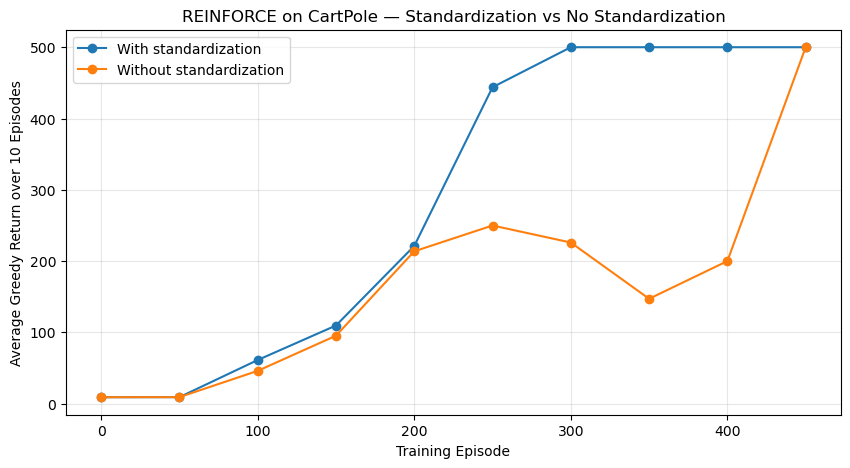

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_std["eval_episode_indices"],
    results_std["eval_avg_returns"],
    label="With standardization",
    marker="o"
)

plt.plot(
    results_nostd["eval_episode_indices"],
    results_nostd["eval_avg_returns"],
    label="Without standardization",
    marker="o"
)

plt.title("REINFORCE on CartPole — Standardization vs No Standardization")
plt.xlabel("Training Episode")
plt.ylabel(f"Average Greedy Return over {EVAL_EPISODES} Episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
def first_episode_reaching(results, threshold=500.0):
    for ep, ret in zip(results["eval_episode_indices"], results["eval_avg_returns"]):
        if ret >= threshold:
            return ep
    return None


summary = {
    "With standardization": {
        "Best eval return": max(results_std["eval_avg_returns"]),
        "Final eval return": results_std["eval_avg_returns"][-1],
        "First episode reaching 500": first_episode_reaching(results_std)
    },
    "Without standardization": {
        "Best eval return": max(results_nostd["eval_avg_returns"]),
        "Final eval return": results_nostd["eval_avg_returns"][-1],
        "First episode reaching 500": first_episode_reaching(results_nostd)
    }
}

for setting, values in summary.items():
    print(setting)
    for key, value in values.items():
        print(f"  {key}: {value}")
    print()

With standardization
  Best eval return: 500.0
  Final eval return: 500.0
  First episode reaching 500: 300

Without standardization
  Best eval return: 500.0
  Final eval return: 500.0
  First episode reaching 500: 450



**The Real Exercise**: Standard practice is to use the state-value function $v(s)$ as a baseline. This is intuitively appealing -- we are more interested in updating out policy for returns that estimate the current **value** worse. Our new update becomes:

$$ \boldsymbol{\theta}_{t+1} \triangleq \boldsymbol{\theta}_t + \alpha (G_t - \tilde{v}(S_t \mid \mathbf{w})) \frac{\nabla \pi(A_t \mid s, \boldsymbol{\theta})}{\pi(A_t \mid s, \boldsymbol{\theta})} $$

where $\tilde{v}(s \mid \mathbf{w})$ is a **deep neural network** with parameters $w$ that estimates $v_\pi(s)$. What neural network? Typically, we use the **same** network architecture as that of the Policy.

**Your Task**: Modify your implementation to fit a second, baseline network to estimate the value function and use it as **baseline**. 

RELOAD

In [23]:
%reload_ext autoreload
%autoreload 2

from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt

from reinforce import PolicyNet, ValueNet, reinforce_baseline

print("Reloaded!")

Reloaded!


Standardize e Value Baseline

In [24]:
SEED = 2112
NUM_EPISODES = 500
EVAL_EVERY = 50
EVAL_EPISODES = 10

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

CHECKPOINT_BASELINE_PATH = CHECKPOINT_DIR / f"cartpole_reinforce_value_baseline_seed{SEED}_best.pt"

torch.manual_seed(SEED)
np.random.seed(SEED)

env = gym.make("CartPole-v1")
env.reset(seed=SEED)
env.action_space.seed(SEED)

policy_bl = PolicyNet(env)
value_net = ValueNet(env)

results_bl = reinforce_baseline(
    policy=policy_bl,
    value_net=value_net,
    env=env,
    gamma=0.98,
    num_episodes=NUM_EPISODES,
    eval_every=EVAL_EVERY,
    eval_episodes=EVAL_EPISODES,
    checkpoint_path=str(CHECKPOINT_BASELINE_PATH),
    log_every=50,
    normalize_advantage=True,
    save_best_on_eval=True
)

env.close()

print(results_bl.keys())
print("Best checkpoint saved in:", results_bl["checkpoint_path"])
print("Best eval return:", results_bl["best_eval_return"])

  [EVAL ep.0] AvgReturn: 9.0 | AvgLength: 9.0
💾 New best baseline model saved! AvgEvalReturn = 9.00

Episode: 0
Train Return: 18.00
Train Avg Return (last 50): 18.00
Train Std Return (last 50): 0.00
Episode Length: 18
Policy Loss: 0.1071
Value Loss: 79.0979
Running Reward: 0.90

  [EVAL ep.50] AvgReturn: 37.4 | AvgLength: 37.4
💾 New best baseline model saved! AvgEvalReturn = 37.40

Episode: 50
Train Return: 26.00
Train Avg Return (last 50): 22.00
Train Std Return (last 50): 12.56
Episode Length: 26
Policy Loss: -0.2671
Value Loss: 109.3444
Running Reward: 19.88

  [EVAL ep.100] AvgReturn: 500.0 | AvgLength: 500.0
💾 New best baseline model saved! AvgEvalReturn = 500.00

Episode: 100
Train Return: 32.00
Train Avg Return (last 50): 22.00
Train Std Return (last 50): 12.33
Episode Length: 32
Policy Loss: -0.4423
Value Loss: 119.9589
Running Reward: 22.19

  [EVAL ep.150] AvgReturn: 500.0 | AvgLength: 500.0

Episode: 150
Train Return: 28.00
Train Avg Return (last 50): 24.62
Train Std Return 

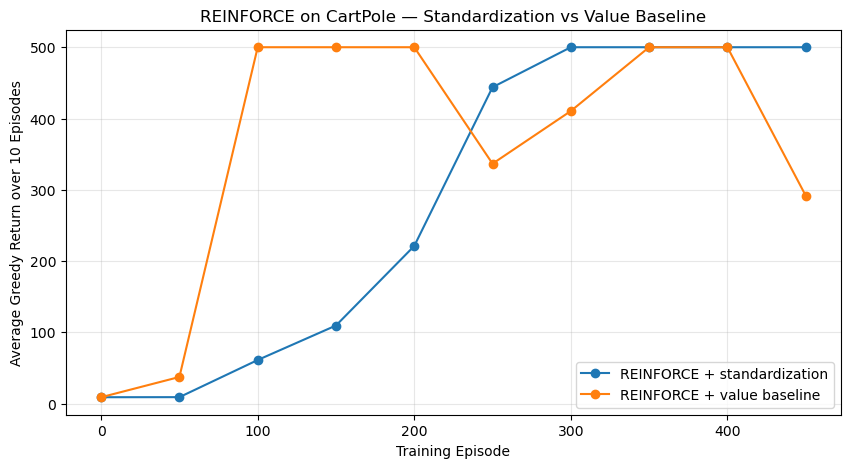

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_std["eval_episode_indices"],
    results_std["eval_avg_returns"],
    label="REINFORCE + standardization",
    marker="o"
)

plt.plot(
    results_bl["eval_episode_indices"],
    results_bl["eval_avg_returns"],
    label="REINFORCE + value baseline",
    marker="o"
)

plt.title("REINFORCE on CartPole — Standardization vs Value Baseline")
plt.xlabel("Training Episode")
plt.ylabel(f"Average Greedy Return over {EVAL_EPISODES} Episodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

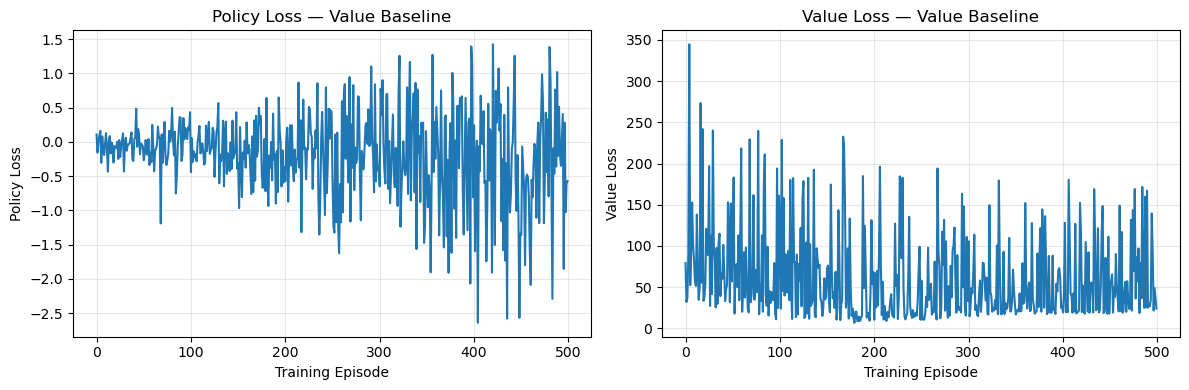

In [26]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results_bl["policy_losses"])
plt.title("Policy Loss — Value Baseline")
plt.xlabel("Training Episode")
plt.ylabel("Policy Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(results_bl["value_losses"])
plt.title("Value Loss — Value Baseline")
plt.xlabel("Training Episode")
plt.ylabel("Value Loss")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
def first_episode_reaching(results, threshold=500.0):
    for ep, ret in zip(results["eval_episode_indices"], results["eval_avg_returns"]):
        if ret >= threshold:
            return ep
    return None


summary = {
    "REINFORCE + standardization": {
        "Best eval return": max(results_std["eval_avg_returns"]),
        "Final eval return": results_std["eval_avg_returns"][-1],
        "First episode reaching 500": first_episode_reaching(results_std)
    },
    "REINFORCE + value baseline": {
        "Best eval return": max(results_bl["eval_avg_returns"]),
        "Final eval return": results_bl["eval_avg_returns"][-1],
        "First episode reaching 500": first_episode_reaching(results_bl)
    }
}

for method, values in summary.items():
    print(method)
    for key, value in values.items():
        print(f"  {key}: {value}")
    print()

REINFORCE + standardization
  Best eval return: 500.0
  Final eval return: 500.0
  First episode reaching 500: 300

REINFORCE + value baseline
  Best eval return: 500.0
  Final eval return: 291.9
  First episode reaching 500: 100



Cartpole finale 

In [28]:
CHECKPOINT_TO_WATCH = "checkpoints/cartpole_reinforce_standardized_seed2112_best.pt"

In [29]:
import time
import gymnasium as gym
import torch

from reinforce import PolicyNet


def watch_saved_cartpole(checkpoint_path, episodes=3, delay=0.02):
    env_watch = gym.make("CartPole-v1", render_mode="human")

    policy = PolicyNet(env_watch)
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    policy.load_state_dict(state_dict)
    policy.eval()

    OBS_SCALE = torch.tensor([4.8, 5.0, 0.418, 5.0], dtype=torch.float32)

    for ep in range(episodes):
        obs, info = env_watch.reset()
        total_reward = 0

        for t in range(500):
            obs_tensor = torch.tensor(obs, dtype=torch.float32) / OBS_SCALE

            with torch.no_grad():
                action = policy(obs_tensor, temperature=1e-8).argmax().item()

            obs, reward, terminated, truncated, info = env_watch.step(action)
            total_reward += reward

            time.sleep(delay)

            if terminated or truncated:
                break

        print(f"Episode {ep + 1}: return = {total_reward:.0f}, length = {t + 1}")

    env_watch.close()


CHECKPOINT_TO_WATCH = "checkpoints/cartpole_reinforce_standardized_seed2112_best.pt"

watch_saved_cartpole(CHECKPOINT_TO_WATCH, episodes=3, delay=0.02)

Episode 1: return = 500, length = 500
Episode 2: return = 500, length = 500
Episode 3: return = 500, length = 500



-----

## Exercise 3: Going Deeper

As usual, pick **AT LEAST ONE** of the following exercises to complete.

### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


### Exercise 3.2: Solving Cartpole and Lunar Lander with `Deep Q-Learning` (harder)

On policy Deep Reinforcement Learning tends to be **very unstable**. Write an implementation (or adapt an existing one) of `Deep Q-Learning` to solve these two environments (Cartpole and Lunar Lander). To do this you will need to implement a **Replay Buffer** and use a second, slow-moving **target Q-Network** to stabilize learning.

**Why choose this exercise?** DQL, similarly to A2C, provides a good starting point for diving into the state-of-the-art in *off-policy* Deep Reinforcement Learning algorithms.

### Exercise 3.3: Solving the OpenAI CarRacing environment (hardest) 

Use `Deep Q-Learning` -- or even better, an off-the-shelf implementation of **Proximal Policy Optimization (PPO)** -- to train an agent to solve the [OpenAI CarRacing](https://github.com/andywu0913/OpenAI-GYM-CarRacing-DQN) environment. This will be the most *fun*, but also the most *difficult*. Some tips:

1. Make sure you use the `continuous=False` argument to the environment constructor. This ensures that the action space is **discrete** (we haven't seen how to work with continuous action spaces).
2. Your Q-Network will need to be a CNN. A simple one should do, with two convolutional + maxpool layers, folowed by a two dense layers. You will **definitely** want to use a GPU to train your agents.
3. The observation space of the environment is a single **color image** (a single frame of the game). Most implementations stack multiple frames (e.g. 3) after converting them to grayscale images as an observation.

**Why choose this exercise?** This exercise is a good simulation of a *real* Deep Reinforcement Learning problem that involves both *perception* and *action* -- just like the problems you might find in the wild. It will require you to think carefully about monitoring performance during training and carefully adapting hyperparameters to learn a good policy for this environment.


### Exercise 3.4: Instruction Fine-tuning an LLM (very hard)

In this exercise you will adapt a small LLM (e.g. `Qwen/Qwen3-0.6B-Base`) on one or more procedural reasoning tasks from the [Reasoning Gym](https://github.com/open-thought/reasoning-gym/tree/main). Adapting LLMs with Reinforcement Learning, however, requires a **ton** of infrastructural code for wrangling data, managing replay buffers, and coordinating batch construction and masking. Thus, it was not possible to come up with a reasonably-dimensioned exercise that can be done *from scratch* like the ones above.

However, for this exercise, you can use the [RLHF Book](https://github.com/natolambert/rlhf-book/tree/main) by Nathan Lambert as a basis for your experimentation. The book contains a wealth of information and -- most importantly -- *code* for implementing RLHF pipelines.

**The Exercise**: Pick an (easy) dataset from the Reasoning Gym, and adapt Qwen to solve it. Anything goes. This is an experimental exercise for this year, so learn something and *have fun*.

**Important**: Just copying the RLHF Book repository and running the code is, obviously, not an acceptable solution for this exercise. I expect you to *reuse* the code from the repository and do something (minimally) different than what is already in the repository. And, as always, whatever you submit, you must be able to explain *everything* it doe.
 